Load Hazard Event Window Dataset

In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("HAZARD_EVENT_WINDOWS.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
df["hazard_time"] = pd.to_datetime(df["hazard_time"], utc=True)

C:\Users\toufi\AppData\Local\Temp\ipykernel_2640\534709503.py:6: DtypeWarning: Columns (0: ts_g, 1: aplicom_g, 2: address_g, 3: advdata_g, 4: geom_g, 5: source_g) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("HAZARD_EVENT_WINDOWS.csv")


Create Time Offset

In [14]:
df["t_offset"] = (df["timestamp"] - df["hazard_time"]).dt.total_seconds()

Create GPS-Based Speed (Required for Speed Plot)

In [15]:


df["lat_shift"] = df.groupby("hazard_id")["lat"].shift(1)
df["lon_shift"] = df.groupby("hazard_id")["lon"].shift(1)

def haversine(lat1, lon1, lat2, lon2):
    R = 6371000  # Radius of Earth (m)
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

df["gps_speed"] = haversine(
    df["lat"], df["lon"], df["lat_shift"], df["lon_shift"]
)

SPEED AROUND HAZARD EVENTS

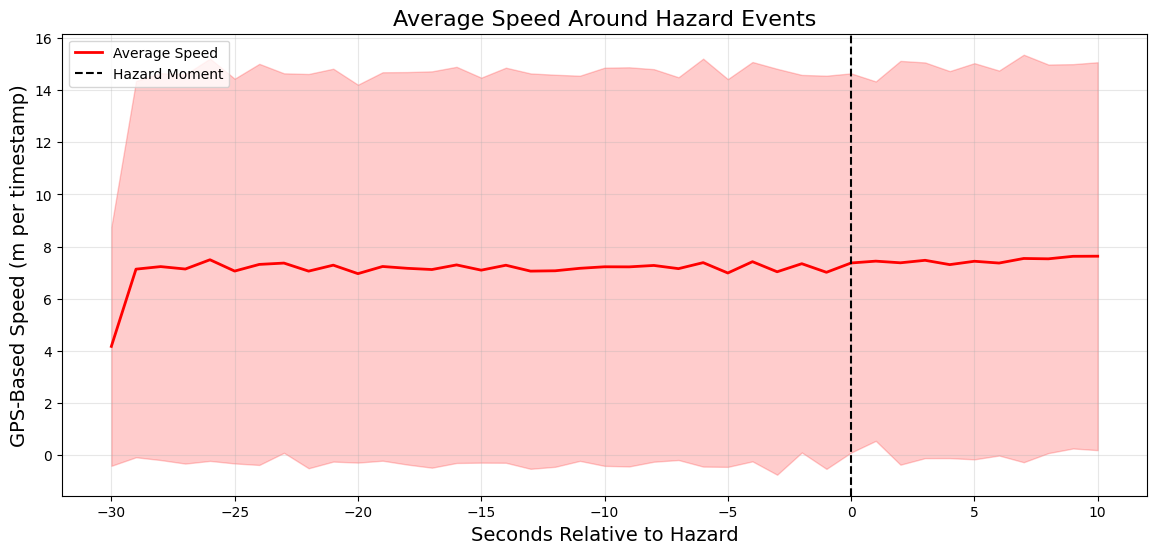

In [16]:

# Compute mean and std
avg = df.groupby("t_offset")["gps_speed"].mean()
std = df.groupby("t_offset")["gps_speed"].std()

plt.figure(figsize=(14,6))

# Average line
plt.plot(avg.index, avg.values, color="red", linewidth=2, label="Average Speed")

# Standard deviation shading
plt.fill_between(avg.index, avg - std, avg + std, color="red", alpha=0.2)

# Hazard moment
plt.axvline(0, color="black", linestyle="--", linewidth=1.5, label="Hazard Moment")

plt.title("Average Speed Around Hazard Events", fontsize=16)
plt.xlabel("Seconds Relative to Hazard", fontsize=14)
plt.ylabel("GPS-Based Speed (m per timestamp)", fontsize=14)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

ACCELERATION AROUND HAZARD

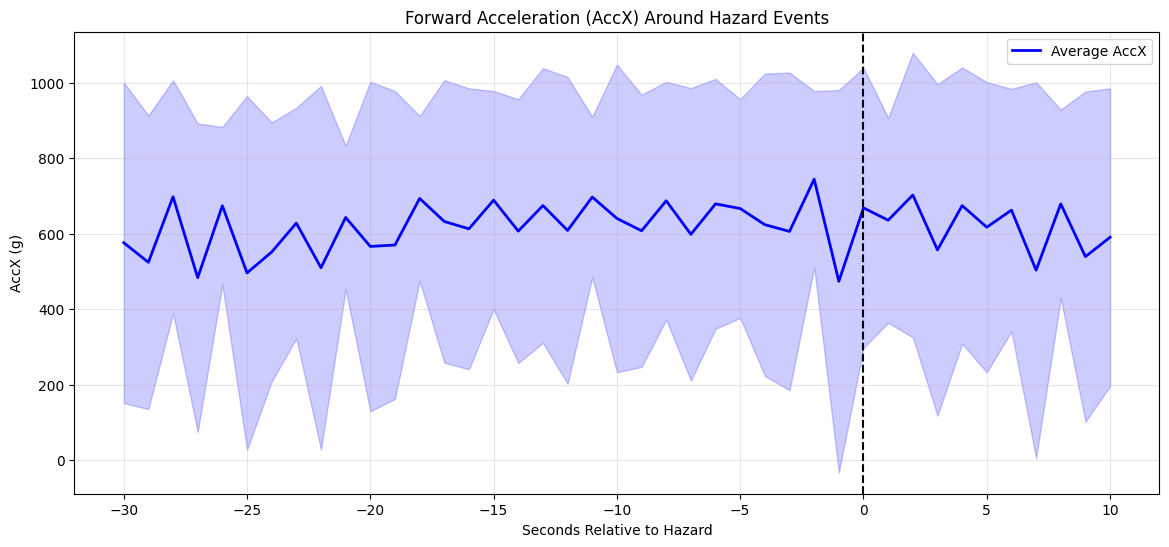

In [17]:
avg_acc = df.groupby("t_offset")["accx_g"].mean()
std_acc = df.groupby("t_offset")["accx_g"].std()

plt.figure(figsize=(14,6))

plt.plot(avg_acc.index, avg_acc.values, color="blue", linewidth=2, label="Average AccX")
plt.fill_between(avg_acc.index, avg_acc - std_acc, avg_acc + std_acc, color="blue", alpha=0.2)

plt.axvline(0, color="black", linestyle="--", linewidth=1.5)
plt.title("Forward Acceleration (AccX) Around Hazard Events")
plt.xlabel("Seconds Relative to Hazard")
plt.ylabel("AccX (g)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

LATERAL ACCELERATION (accy_g)

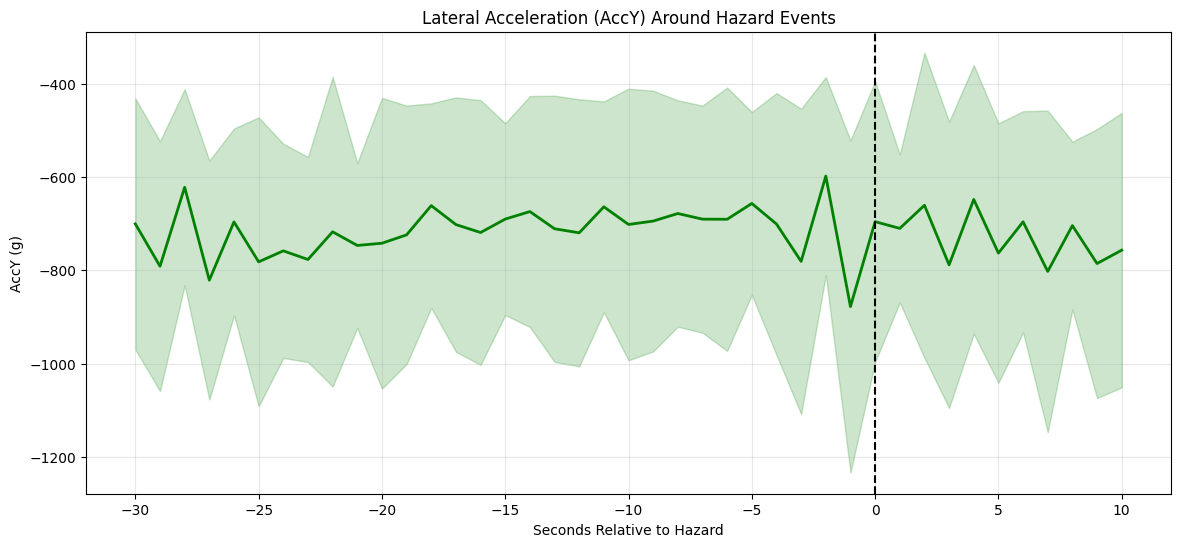

In [18]:
avg_lat = df.groupby("t_offset")["accy_g"].mean()
std_lat = df.groupby("t_offset")["accy_g"].std()

plt.figure(figsize=(14,6))

plt.plot(avg_lat.index, avg_lat.values, color="green", linewidth=2)
plt.fill_between(avg_lat.index, avg_lat - std_lat, avg_lat + std_lat, color="green", alpha=0.2)

plt.axvline(0, color="black", linestyle="--", linewidth=1.5)
plt.title("Lateral Acceleration (AccY) Around Hazard Events")
plt.xlabel("Seconds Relative to Hazard")
plt.ylabel("AccY (g)")
plt.grid(alpha=0.3)
plt.show()

SURFACE CONDITION VISUALIZATION

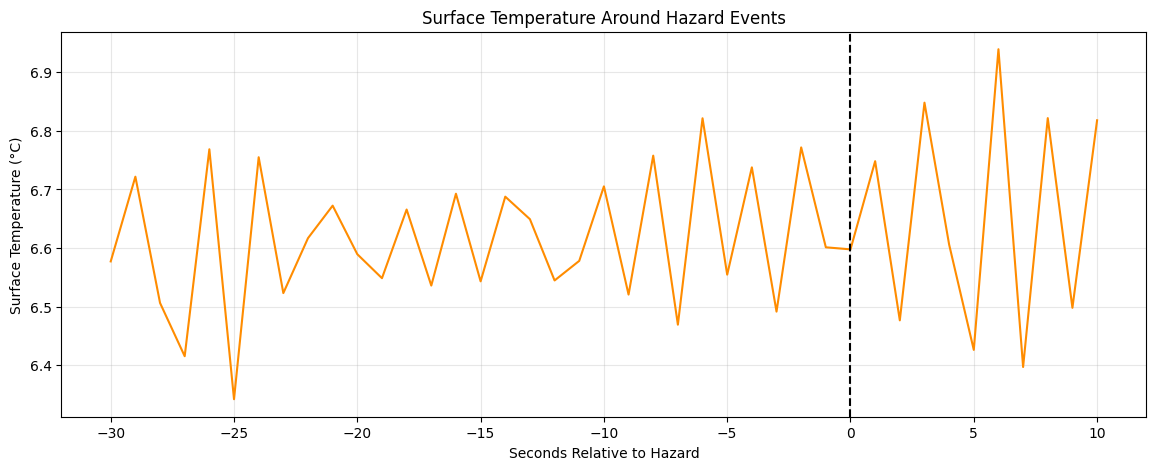

In [19]:
avg_temp = df.groupby("t_offset")["surface_temperature"].mean()

plt.figure(figsize=(14,5))
plt.plot(avg_temp.index, avg_temp.values, color="darkorange")
plt.axvline(0, color="black", linestyle="--")
plt.title("Surface Temperature Around Hazard Events")
plt.xlabel("Seconds Relative to Hazard")
plt.ylabel("Surface Temperature (°C)")
plt.grid(alpha=0.3)
plt.show()

VISUALIZE HAZARD LOCATIONS ON MAP

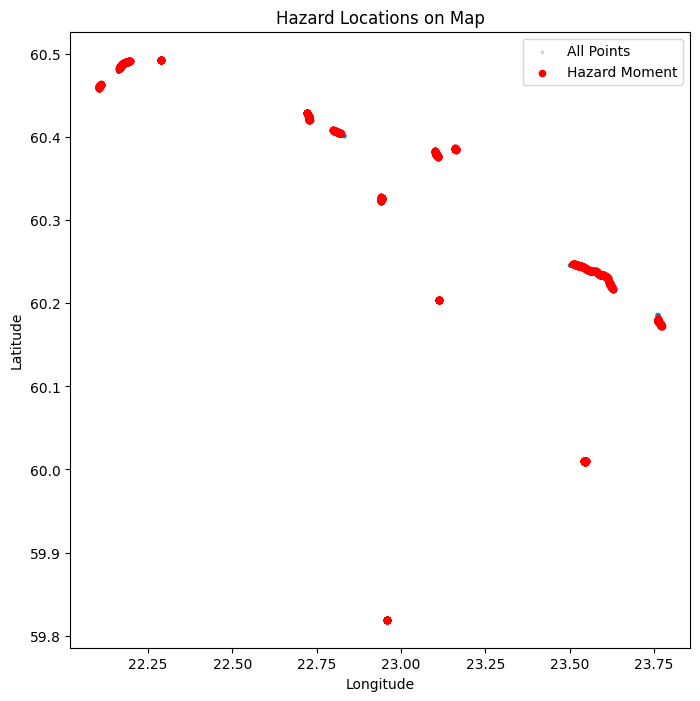

In [20]:
plt.figure(figsize=(8,8))
plt.scatter(df["lon"], df["lat"], s=3, alpha=0.2, label="All Points")
plt.scatter(df[df["t_offset"]==0]["lon"], df[df["t_offset"]==0]["lat"], color="red", s=20, label="Hazard Moment")

plt.title("Hazard Locations on Map")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.show()